# 多层感知机

## 激活函数

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

### ReLU函数

$$ReLU(x) = max(x, 0)$$

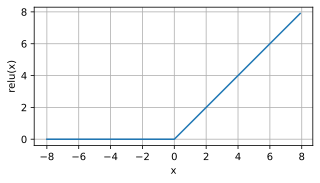

In [2]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

当输⼊为负时，ReLU函数的导数为0，⽽当输⼊为正时，ReLU函数的导数为1。\
注意，当输⼊值精确等于0时，ReLU函数不可导。\
在此时，我们默认使⽤左侧的导数，即当输⼊为0时导数为0。\
我们可以忽略这种情况，因为输⼊可能永远都不会是0。

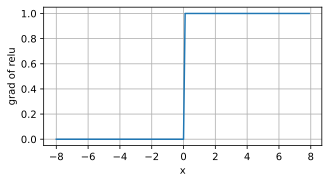

In [3]:
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

**参数化ReLU**
$$pReLU(x) = max(0, x) + \alpha min(0, x)$$

### sigmoid函数

**它将范围（-inf, inf）中的任意输⼊压缩到区间（0, 1）中的某个值:**

$$sigmoid(x) = \frac{1}{1 + exp(-x)}$$

当我们想要将输出视作⼆元分类问题的概率时，sigmoid仍然被⼴泛⽤作输出单元上的激活函数（sigmoid可以视为softmax的特例）。

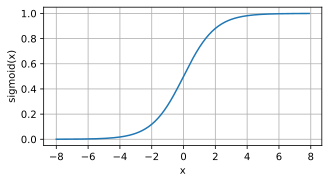

In [4]:
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

**sigmoid函数的导数为下面的公式:**

$$\frac{d}{dx}sigmoid(x) = \frac{exp(-x)}{(1 + exp(-x))^2} = sigmoid(x)(1 - sigmoid(x))$$


**当输⼊为0时，sigmoid函数的导数达到最⼤值0.25;\
⽽输⼊在任⼀⽅向上越远离0点时，导数越接近0。**

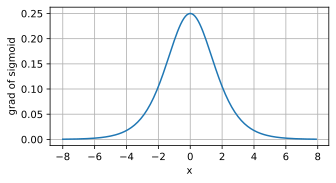

In [5]:
#清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

### tanh函数

$$tanh(x) = \frac{1 - exp(-2x)}{1 + exp(-2x)}$$

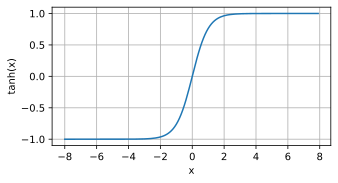

In [6]:
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

**tanh函数的导数是：**

$$\frac{d}{dx}tanh(x) = 1 - tanh^2(x)$$

当输⼊接近0时，tanh函数的导数接近最⼤值1。\
与我们在sigmoid函数图像中看到的类似，输⼊在任⼀⽅向上越远离0点，导数越接近0。

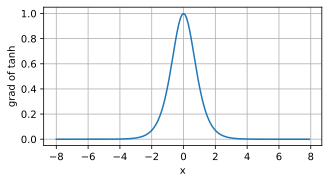

In [7]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

## 多层感知机的从零开始实现

In [8]:
import torch
from torch import nn
from d2l import torch as d2l

In [9]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 初始化模型参数

In [10]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) *0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

### 激活函数

In [11]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

### 模型

In [12]:
def net(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X@W1 + b1) # @代表矩阵乘法
    return (H@W2 + b2)

### 损失函数

In [13]:
loss = nn.CrossEntropyLoss(reduction='none')

### 训练

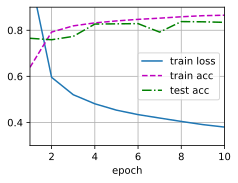

In [14]:
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

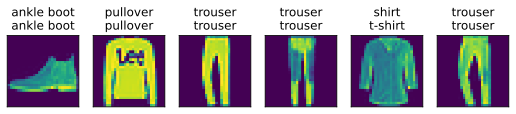

In [15]:
d2l.predict_ch3(net, test_iter)

## 多层感知机的简洁实现

In [16]:
import torch
from torch import nn
from d2l import torch as d2l

### 模型

In [17]:
net = nn.Sequential(nn.Flatten(), 
                    nn.Linear(784, 256), 
                    nn.ReLU(), 
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [18]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

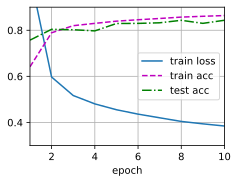

In [19]:
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## 模型选择、欠拟合和过拟合

### K折交叉验证

当训练数据稀缺时，我们甚⾄可能⽆法提供⾜够的数据来构成⼀个合适的验证集。这个问题的⼀个流⾏的解决⽅案是采⽤K折交叉验证。这⾥，原始训练数据被分成K个不重叠的⼦集。然后执⾏K次模型训练和验证，每次在K − 1个⼦集上进⾏训练，并在剩余的⼀个⼦集（在该轮中没有⽤于训练的⼦集）上进⾏验证。最后，通过对K次实验的结果取平均来**估计训练和验证误差**。

### 多项式回归

In [20]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

### 生成数据集

In [21]:
max_degree = 20 # 多项式的最大阶数
n_train, n_test = 100, 100 # 训练和测试数据集大小
true_w = np.zeros(max_degree) # 分配大量空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1) # gamma(n)=(n-1)!
#labels的维度：(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [22]:
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32)
                                             for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.1018],
         [ 0.4034]]),
 tensor([[ 1.0000e+00, -1.0184e-01,  5.1862e-03, -1.7606e-04,  4.4828e-06,
          -9.1310e-08,  1.5499e-09, -2.2550e-11,  2.8708e-13, -3.2486e-15,
           3.3085e-17, -3.0632e-19,  2.5998e-21, -2.0367e-23,  1.4816e-25,
          -1.0060e-27,  6.4034e-30, -3.8362e-32,  2.1706e-34, -1.1635e-36],
         [ 1.0000e+00,  4.0343e-01,  8.1379e-02,  1.0944e-02,  1.1038e-03,
           8.9058e-05,  5.9882e-06,  3.4512e-07,  1.7404e-08,  7.8014e-10,
           3.1474e-11,  1.1543e-12,  3.8807e-14,  1.2043e-15,  3.4704e-17,
           9.3339e-19,  2.3535e-20,  5.5852e-22,  1.2518e-23,  2.6580e-25]]),
 tensor([4.9269, 5.3426]))

### 对模型进行训练和测试

In [23]:
def evaluate_loss(net, data_iter, loss):
    metric = d2l.Accumulator(2) # 损失的总和，样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())

    return metric[0] / metric[1]

In [24]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch',ylabel='loss', yscale='log', xlim=[1, num_epochs],
                             ylim=[1e-3, 1e2], legend=['train', 'test'])
    
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))

    print('weight:', net[0].weight.data.numpy())

### 三阶多项式函数拟合(正常)

weight: [[ 4.98992    1.228408  -3.392944   5.5083666]]


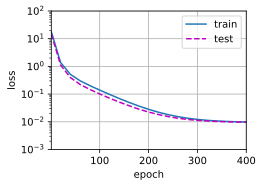

In [25]:
# 首先使用三阶多项式
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

### 线性函数拟合(⽋拟合)

weight: [[3.275756  3.3624787]]


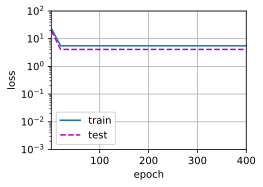

In [26]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

### ⾼阶多项式函数拟合(过拟合)

weight: [[ 4.9693961e+00  1.2546911e+00 -3.2966523e+00  5.2165680e+00
  -2.7669281e-01  1.3608557e+00 -7.0213847e-02  1.2745605e-01
  -6.2022999e-02  2.3520077e-03 -1.8147295e-02 -1.3679396e-01
  -1.8458195e-01 -1.7707421e-01 -8.6004876e-02  3.8286064e-02
   1.1875221e-01 -4.3544322e-02 -4.7374919e-02  1.9509557e-01]]


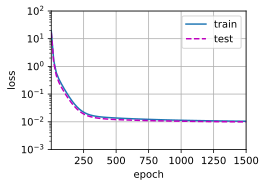

In [27]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs=1500)

## 权重衰减

$L_2$正则化对权重向量的⼤分量施加了巨⼤的惩罚。这使得我们的学习算法偏向于在⼤量特征上均匀分布权重的模型。\
在实践中，这可能使它们对单个变量中的观测误差更为稳定。

相⽐之下，惩罚会导致模型将权重集中在⼀⼩部分特征上，⽽将其他权重清除为零。\
这称为特征选择（featureselection），这可能是其他场景下需要的。

**正则化系数$\lambda$也是超参数**

加入正则化后通过以下式子计算损失：
$$L(\pmb{w}, b) + \frac{\lambda}{2}\lVert w \rVert^2$$

其中$L(\pmb{w}, b)$是损失函数，$\lVert \pmb{w} \rVert^2$是对当前权重$\pmb{w}$的$L_2$范数

在这⾥我们使⽤平⽅范数⽽不是标准范数,这样做是为了便于计算。\
通过平⽅范数，我们去掉平⽅根，留下权重向量每个分量的平⽅。\
这使得惩罚的导数很容易计算：导数的和等于和的导数。

### 高维线性回归

In [28]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [29]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

### 从零开始实现

#### 初始化模型参数

In [30]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

#### 定义$L_2$范数惩罚

In [31]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

#### 定义训练代码实现

In [32]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log', 
                            xlim=[5, num_epochs], legend=['train', 'test'])
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                    d2l.evaluate_loss(net, test_iter, loss)))
        
    print('w的L2范数是：', torch.norm(w).item())

#### 忽略正则化直接训练

w的L2范数是： 14.197759628295898


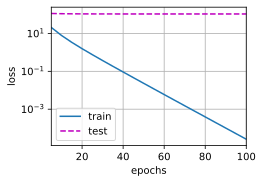

In [33]:
train(lambd=0)

#### 使用权重衰减

w的L2范数是： 0.34193524718284607


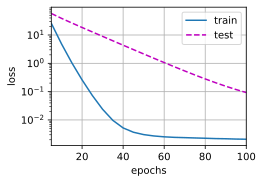

In [34]:
train(lambd=3)

### 简洁实现

In [35]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {'params':net[0].weight, 'weight_decay':wd},
        {'params':net[0].bias}], lr = lr)

    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()

        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                    d2l.evaluate_loss(net, test_iter, loss)))
    
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 14.036666870117188


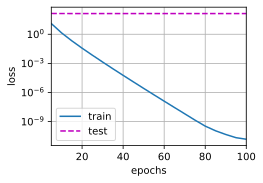

In [36]:
train_concise(0)

w的L2范数： 0.38093623518943787


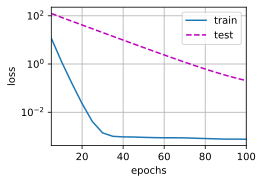

In [37]:
train_concise(3)

## 暂退法

在标准暂退法正则化中，通过按保留（未丢弃）的节点的分数进⾏规范化来消除每⼀层的偏差。换⾔之，每个中间活性值h以暂退概率p由随机变量h′替换，如下所⽰：

$$
h' = \begin{cases}
0 \quad 概率为p\\
\frac{h}{1 - p} \quad 其他情况
\end{cases}
$$

**根据此模型的设计，其期望值保持不变，即$E[h^′] = h$。**

### 从零开始实现

In [38]:
import torch
from torch import nn
from d2l import torch as d2l

In [39]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 在本情况中,所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 在本情况中，所有元素都被保留
    if dropout == 0:
        return X
    
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [40]:
X = torch.arange(16, dtype=torch.float32).reshape(2, 8)
print(X)
print(dropout_layer(X, 0))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  4.,  6.,  8.,  0., 12., 14.],
        [16.,  0., 20.,  0.,  0., 26., 28., 30.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


#### 定义模型参数

In [41]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

#### 定义模型

**常见的技巧是在靠近输入层的地方设置较低的暂退概率**

In [42]:
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, 
                    dropout1 = 0.2, dropout2 = 0.5, is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()
        self.dropout1 = dropout1
        self.dropout2 = dropout2

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape(-1, self.num_inputs)))
        # 只有在训练时才使用dropout
        if self.training == True:
            H1 = dropout_layer(H1, self.dropout1)

        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2, self.dropout2)

        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

#### 训练和测试

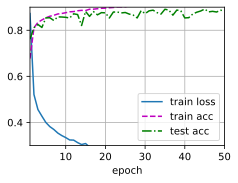

In [43]:
num_epochs, lr, batch_size = 50, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

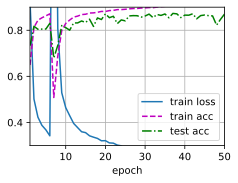

In [44]:
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2, dropout1=0, dropout2=0)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

### 简洁实现

In [45]:
net = nn.Sequential(nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            # 在第一个全连接层后添加一个dropout层
            nn.Dropout(dropout1),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

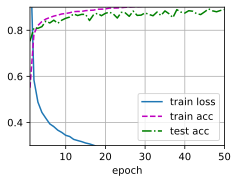

In [46]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## 数值稳定性和模型初始化

### 梯度消失和梯度爆炸

#### 梯度消失

**sigmoid函数为什么会导致梯度消失**

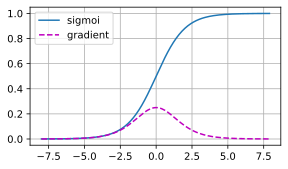

In [47]:
%matplotlib inline
import torch
from d2l import torch as d2l

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
        legend=['sigmoi', 'gradient'], figsize=(4.5, 2.5))

正如上图，当sigmoid函数的输⼊很⼤或是很⼩时，它的梯度都会消失。

#### 梯度爆炸

梯度爆炸可能同样令⼈烦恼。为了更好地说明这⼀点，我们⽣成100个⾼斯随机矩阵，并将它们与某个初始矩阵相乘。对于我们选择的尺度（⽅差σ
2 = 1），矩阵乘积发⽣爆炸。**当这种情况是由于深度⽹络的初始化所导致时，我们没有机会让梯度下降优化器收敛。**

In [48]:
M = torch.normal(0, 1, size=(4, 4))
print('一个矩阵 \n', M)
for i in range(100):
    M = torch.mm(M, torch.normal(0, 1, size=(4, 4)))

print('乘以100个矩阵后\n', M)

一个矩阵 
 tensor([[-0.7825,  0.1439, -0.4463, -0.5464],
        [-1.9318,  0.4880,  0.7864, -1.4916],
        [-2.5624,  0.3141, -0.6265,  1.2686],
        [ 0.5295,  0.1276, -0.7820, -0.6803]])
乘以100个矩阵后
 tensor([[-3.6119e+26,  4.2323e+27, -3.5188e+27, -3.1017e+27],
        [-4.0663e+26,  4.7647e+27, -3.9615e+27, -3.4919e+27],
        [ 4.9155e+25, -5.7598e+26,  4.7889e+26,  4.2212e+26],
        [-3.8960e+26,  4.5652e+27, -3.7956e+27, -3.3457e+27]])


#### Xavier初始化

**通常，Xavier初始化从均值为零，⽅差$\sigma^2 = \frac{2}{n_in + n_out}$的⾼斯分布中采样权重。**

## 环境和分布偏移

### 分布偏移纠正

跳了\
练习中的[实现协变量偏移纠正]很好

## 实战Kaggle比赛：预测房价

### 下载和缓存数据集

In [49]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

In [50]:
def download(name, cache_dir=os.path.join('..', 'data')):#@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f'{name} 不存在于 {DATA_HUB}'
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [51]:
def download_extract(name, folder=None): #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.Zipfile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all(): #@save
        """下载DATA_HUB中的所有文件"""
        for name in DATA_HUB:
            download(name)

### 访问和读取数据集

In [52]:
%matplotlib inline
import torch
from torch import nn
import numpy as np
import pandas as pd
from d2l import torch as d2l

In [53]:
DATA_HUB['kaggle_house_train'] = (DATA_URL + 'kaggle_house_pred_train.csv', '585e9cc93e70b39160e7921475f9bcd7d31219ce')
DATA_HUB['kaggle_house_test'] = (DATA_URL + 'kaggle_house_pred_test.csv','fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [54]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

In [55]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [56]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [57]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

### 数据预处理

为了将所有特征放在⼀个共同的尺度上，我们通过将特征重新缩放到零均值和单位⽅差来标准化数据：
$$x \leftarrow \frac{x - \mu}{\sigma}$$

现在，这些特征具有零均值和单位⽅差，即$E[\frac{x-\mu}{\sigma}]=\frac{\mu - \mu}{\sigma} = 0$和
$E[(x - \mu)^2] = (\sigma^2 + \mu^2) - 2\mu^2 + \mu^2 = \sigma^2$

直观地说，我们标准化数据有两个原因：⾸先，它⽅便优化。其次，因为我们不知道哪些特征是相关的，所以我们不想让惩罚分配给⼀个特征的系数⽐分配给其他任何特征的系数更⼤。

In [58]:
# 若⽆法获得测试数据，则可根据训练数据计算均值和标准差

# 'object'代表字符串/混合类型
# .index 提取这些列的列名
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index 
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x - x.mean()) / x.std())

# 在标准化数据之后，所有均值消失，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [59]:
# 用独热编码替换离散值，例如“MSZoning”包含值“RL”和“Rm”。我们将创建两个新的指⽰器特征“MSZoning_RL”和“MSZoning_RM”，其值为0或1。
# 'Dummy_na=True'将'na'(缺失值)视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True).to_numpy(dtype=np.float32)
all_features.shape

(2919, 330)

In [60]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train], dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:], dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

### 训练

In [61]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

房价就像股票价格⼀样，我们关⼼的是相对数量，⽽不是绝对数量。因此，我们更关⼼相对误差$\frac{y-\hat{y}}{y}$，⽽不是
绝对误差$y − \hat{y}$。例如，如果我们在俄亥俄州农村地区估计⼀栋房⼦的价格时，假设我们的预测偏差了10万美元，然⽽那⾥⼀栋典型的房⼦的价值是12.5万美元，那么模型可能做得很糟糕。另⼀⽅⾯，如果我们在加州豪宅区的预测出现同样的10万美元的偏差，（在那⾥，房价中位数超过400万美元）这可能是⼀个不错的预测。


解决这个问题的⼀种⽅法是⽤价格预测的对数来衡量差异:
$$\sqrt{\frac{1}{n} \sum_{i=1}^n (\log{y_i} - \log{\hat{y_i}})^2}$$

In [62]:
def log_rmse(net, features, labels):
    # 为了再取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))

    return rmse.item()

In [63]:
def train(net, train_features, train_labels, test_features, test_labels,
        num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用的时Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))

    return train_ls, test_ls   

In [64]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    
    return X_train, y_train, X_valid, y_valid

In [65]:
# 在K折交叉验证中训练K次后，返回训练和验证误差的平均值
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)

        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                    xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                    legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}, 训练log rmse{float(train_ls[-1]):f},'
                f'验证log rmse{float(valid_ls[-1]):f}')

    
    return train_l_sum / k, valid_l_sum / k

折1, 训练log rmse0.170129,验证log rmse0.157317
折2, 训练log rmse0.162140,验证log rmse0.189980
折3, 训练log rmse0.163696,验证log rmse0.167883
折4, 训练log rmse0.167509,验证log rmse0.154458
折5, 训练log rmse0.162888,验证log rmse0.182728
5-折验证：平均训练log rmse:0.165272平均验证log rmse：0.170473


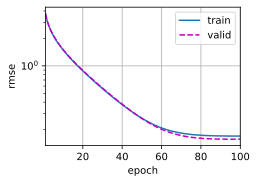

In [66]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'{k}-折验证：平均训练log rmse:{float(train_l):f}'
        f'平均验证log rmse：{float(valid_l):f}')

### 提交Kaggle预测

In [67]:
def train_and_pred(train_features, test_features, train_labels, test_data, 
                    num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
                ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162401


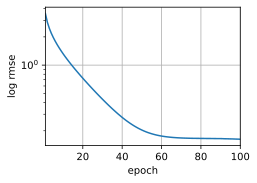

In [68]:
train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size)